# Aprendizaje No Supervisado

En esta sección se aplicarán técnicas de aprendizaje no supervisado para identificar patrones y agrupaciones naturales dentro de las reseñas de productos de Sephora.

A diferencia del aprendizaje supervisado, este tipo de análisis no utiliza una variable objetivo para entrenar el modelo. En su lugar, el algoritmo intenta descubrir automáticamente similitudes entre los registros y formar grupos con características parecidas.

Durante el desarrollo de este análisis se realizarán las siguientes etapas:

1. Preparación de los datos utilizando el dataset previamente preprocesado.
2. Búsqueda del número óptimo de clusters mediante los métodos Elbow Method y Silhouette Score.
3. Entrenamiento del modelo K-Means utilizando el valor de K más adecuado.
4. Reducción de dimensionalidad mediante PCA, con el objetivo de representar visualmente los clusters en dos dimensiones.
5. Análisis e interpretación de los grupos encontrados por el modelo.

### Importación de librerías y configuración del entorno

En esta etapa se importan las librerías necesarias para desarrollar el análisis de clustering y visualización de datos.

Se utilizan herramientas de:

- Manipulación de datos (pandas, numpy)
- Visualización (matplotlib, seaborn)
- Clustering (KMeans)
- Reducción de dimensionalidad (PCA)
- Evaluación de clusters (silhouette_score)

Además, se define la ruta del dataset preprocesado y una semilla aleatoria (random_state) para asegurar resultados reproducibles.

In [3]:
# Se importan las librerias
import os
import numpy as np
import pandas as pd

# Se importan las librerias para visualización
import matplotlib.pyplot as plt
import seaborn as sns

# Se importan las librerias para modelos y aprendizaje no supervisado
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

# Se importan la libreria para el escalado de datos
from sklearn.preprocessing import StandardScaler

# Se configura el estilo de los gráficos
sns.set_context("talk")

RANDOM_STATE = 42
# Ruta del dataset procesado
DATA_PATH = "../data/processed/sephora_limpio.csv"

print("Ruta de datos:", os.path.abspath(DATA_PATH))


Ruta de datos: c:\Users\SSDD\Documents\GitHub\DataSet-Productos-Cosmeticos\data\processed\sephora_limpio.csv


### Carga y verificación del dataset preprocesado

En esta etapa se carga el dataset previamente transformado mediante el pipeline de preprocesamiento.  
Además, se verifica que el archivo exista correctamente y se revisa la estructura general del dataset, incluyendo:

- Que el archivo exista correctamente.
- Dimensiones del DataFrame.
- Variables disponibles.
- Verificación de la presencia de la variable objetivo `is_recommended`.

Aunque el aprendizaje no supervisado no utiliza etiquetas para entrenar el modelo, esta validación permite confirmar que el dataset fue procesado correctamente y mantiene su estructura esperada.

In [4]:
# Se carga el dataset ya preprocesado y verfica que el archivo existe antes de intentar cargarlo
if not os.path.exists(DATA_PATH):
    # Si el archivo no existe, se lanza un error con un mensaje claro
    raise FileNotFoundError(
        f"No existe el archivo: {DATA_PATH}. "
        "Verifica que ya ejecutaste el pipeline de preprocesamiento y que se generó data/processed/sephora_limpio.csv"
    )

# Se carga del dataset
df = pd.read_csv(DATA_PATH)

# Información general del dataframe
print("Dimensiones del dataset:", df.shape)

print("\nColumnas disponibles::")
print(df.columns.tolist())

print("\n¿Existe la variable objetivo 'is_recommended'? ->",
      "is_recommended" in df.columns)


Dimensiones del dataset: (1097385, 44)

Columnas disponibles::
['price_usd', 'rating', 'helpfulness', 'total_feedback_count', 'total_neg_feedback_count', 'total_pos_feedback_count', 'brand_name_belif', 'brand_name_clinique', 'brand_name_dermalogica', 'brand_name_dr jart', 'brand_name_drunk elephant', 'brand_name_farmacy', 'brand_name_first aid beauty', 'brand_name_fresh', 'brand_name_glow recipe', 'brand_name_laneige', 'brand_name_murad', 'brand_name_olehenriksen', 'brand_name_origins', 'brand_name_peter thomas roth', 'brand_name_sunday riley', 'brand_name_tatcha', 'brand_name_the inkey list', 'brand_name_the ordinary', 'brand_name_youth to the people', 'brand_name_infrequent_sklearn', 'skin_type_combination', 'skin_type_dry', 'skin_type_normal', 'skin_type_oily', 'eye_color_blue', 'eye_color_brown', 'eye_color_gray', 'eye_color_green', 'eye_color_grey', 'eye_color_hazel', 'hair_color_auburn', 'hair_color_black', 'hair_color_blonde', 'hair_color_brown', 'hair_color_brunette', 'hair_col

### Preparación de los datos para clustering

En aprendizaje no supervisado no existe una variable objetivo, por lo que se utilizan directamente todas las variables disponibles del dataset preprocesado.

En esta etapa:
- Se crea la matriz de características (`X`).
- Se asegura que todas las variables sean numéricas.
- Se verifican posibles valores nulos para evitar errores durante el entrenamiento de K-Means.

Como se trata de aprendizaje no supervisado, el algoritmo trabajará directamente sobre las características disponibles para encontrar agrupaciones similares entre las observaciones.

In [5]:
# Se preparan los datos para aprendizaje no supervisado

# En clustering no se utiliza variable objetivo,
# por lo que se trabajará con todas las variables disponibles.
X = df.copy()

# Se mantiene una copia del dataset original
# para posteriormente agregar las etiquetas de clusters.
df_original = df.copy()

# Seguridad: convertir todas las variables a formato numérico
X = X.apply(pd.to_numeric, errors="coerce")

# Se eliminan columnas no numéricas si aparecen
X = df.select_dtypes(include=[np.number]).copy()

# Manejo defensivo de valores nulos
if X.isna().any().any():
    X = X.fillna(0.0)

print("Dimensión de la matriz de features:", X.shape)

Dimensión de la matriz de features: (1097385, 44)


### Búsqueda del número óptimo de clusters

Uno de los pasos más importantes en K-Means es determinar cuántos grupos o clusters deben formarse.

Para ello, se evaluaron distintos valores de K utilizando dos métricas principales:

- **Inertia (Elbow Method):** mide la compactación interna de los clusters.
- **Silhouette Score:** evalúa qué tan bien separados están los grupos generados.

Debido al gran tamaño del dataset, se utilizó una muestra aleatoria de 50.000 registros para reducir el tiempo de procesamiento y facilitar el entrenamiento de los modelos.

In [6]:
# Se toma una muestra aleatoria del dataset para no sobrecargar el computador
sample_X = X.sample(50000, random_state=RANDOM_STATE)

print("Dimensión de la muestra:", sample_X.shape)

# Se ve el rango de valores para cada variable de 2 a 11 clusters
k_values = list(range(2, 11))

# Se hacen listas para almacenar metricas
inertias = []
silhouettes = []

# Se itera sobre cada valor de k, se entrena el modelo y se calculan las métricas
for k in k_values:
    print(f"Evaluando k={k} ...")

    # Se entrena el modelo de KMeans con el número de clusters actual
    kmeans = KMeans(
        n_clusters=k,
        n_init="auto",
        random_state=RANDOM_STATE
    )

    # Se ajusta eñ modelo y se obtienen las etiquetas de cluster para cada muestra
    labels = kmeans.fit_predict(sample_X)

    # Esto suma las distancias dentro de cada cluster a su centroide, es decir, la inercia total del modelo
    inertias.append(kmeans.inertia_)

    # Silhouette, mide que tan bien separados están los clusters
    # Los valores cercanos a 1 indican que tienen una mejor separación
    sil = silhouette_score(sample_X, labels)
    silhouettes.append(sil)

# Se organiza el dataframe
k_results = pd.DataFrame({
    "k": k_values,
    "inertia": inertias,
    "silhouette": silhouettes,
})

# Se muestra los resultados
k_results

Dimensión de la muestra: (50000, 44)
Evaluando k=2 ...
Evaluando k=3 ...
Evaluando k=4 ...
Evaluando k=5 ...
Evaluando k=6 ...
Evaluando k=7 ...
Evaluando k=8 ...
Evaluando k=9 ...
Evaluando k=10 ...


,k,inertia,silhouette
0,2,315189.802748,0.310007
1,3,274444.259713,0.209474
2,4,253396.404967,0.159835
3,5,236062.797417,0.165141
4,6,219327.701712,0.170197
5,7,212956.966757,0.165024
6,8,205123.002663,0.136940
7,9,197496.309467,0.140213
8,10,193937.634368,0.137668


In [7]:
# Se selecciona el valor de K con mejor Silhouette Score
best_k = k_results.loc[
    k_results["silhouette"].idxmax(),
    "k"
]

print("Mejor número de clusters según Silhouette:", best_k)

Mejor número de clusters según Silhouette: 2


### Método del Codo (Elbow Method)

El método del codo permite analizar cómo cambia la inercia a medida que aumenta el número de clusters.

La idea principal es identificar el punto donde la mejora comienza a disminuir considerablemente, formando una especie de “codo” en la gráfica.

Ese punto suele representar un equilibrio entre:

- Tener grupos suficientemente diferenciados.
- Evitar crear demasiados clusters innecesarios.

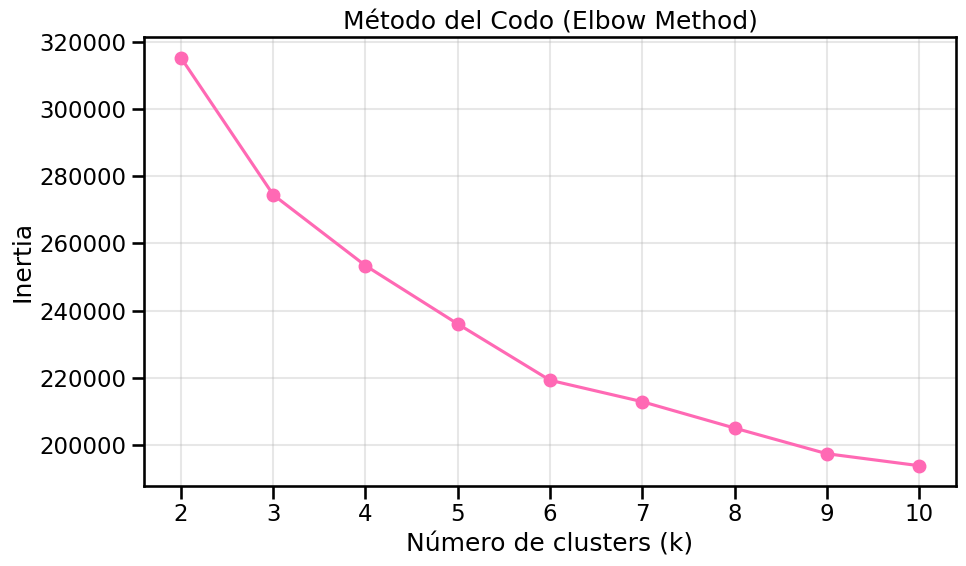

In [8]:
plt.figure(figsize=(10, 6))

# Gráfico de Inertia vs número de clusters
plt.plot(
    k_results["k"],
    k_results["inertia"],
    marker="o",
    color="hotpink"
)

# Configuración del gráfico
plt.xticks(k_results["k"])
plt.title("Método del Codo (Elbow Method)")
plt.xlabel("Número de clusters (k)")
plt.ylabel("Inertia")

plt.grid(True, alpha=0.3)
plt.tight_layout()

# Mostrar gráfico
plt.show()

### Interpretación de Resultados

Al analizar el comportamiento de la curva de izquierda a derecha, se observan los siguientes patrones:

1. **Fase de descenso pronunciado ($k = 2$ a $k = 6$):** Al añadir clusters en este rango, la inercia disminuye de forma drástica. Esto significa que cada nuevo grupo aporta una separación real y significativa en los datos.
2. **Punto de inflexión ($k = 6$):** En este valor se forma claramente el "codo" de la gráfica. Es el momento exacto donde la pendiente cambia de dirección.
3. **Fase de estabilización ($k > 6$):** A partir de los 6 clusters, la línea se aplana notablemente. Agregar un 7° o 8° grupo apenas disminuye la inercia, lo que significa que estaríamos sobrecomplicando el modelo sin obtener un beneficio real de segmentación.

### Entrenamiento final del modelo K-Means

Una vez identificado el número óptimo de clusters, se entrena el modelo final de K-Means utilizando el valor de K seleccionado.

Posteriormente, el modelo asigna una etiqueta de cluster a cada observación del dataset, permitiendo segmentar los registros según características similares encontradas automáticamente por el algoritmo.

Esto facilita el análisis de patrones y comportamientos dentro de las reseñas y características de los productos.

In [9]:
# Se entrena el modelo utilizando el número óptimo de clusters obtenido previamente
kmeans_best = KMeans(
    n_clusters=best_k,
    n_init="auto",
    random_state=RANDOM_STATE
)

# Se asigna un cluster a cada observación
cluster_labels = kmeans_best.fit_predict(X)

# Se agrega la etiqueta del cluster al dataframe original
cluster_col = "cluster_kmeans"
df_original[cluster_col] = cluster_labels

# Se muestra la información general
print("Columna agregada:", cluster_col)

print("\nDistribución de clusters:")
print(df_original[cluster_col].value_counts().sort_index())

# Se visualiza las primeras filas
df_original[[cluster_col]].head()

Columna agregada: cluster_kmeans

Distribución de clusters:
cluster_kmeans
0    809670
1    287715
Name: count, dtype: int64


,cluster_kmeans
0,0
1,0
2,0
3,0
4,0


### Reducción de dimensionalidad con PCA y visualización de clusters

Debido a la alta cantidad de variables presentes en el dataset, resulta difícil visualizar directamente los clusters generados por K-Means.

Para facilitar la interpretación, se aplicó PCA (Principal Component Analysis), una técnica de reducción de dimensionalidad que transforma las variables originales en nuevos componentes principales que conservan la mayor cantidad posible de información.

En este caso:

- Se redujo el dataset a 2 componentes principales (PC1 y PC2).
- Se utilizó una muestra aleatoria de registros para mejorar la visualización del gráfico.
- Cada punto representa una observación del dataset y su color indica el cluster asignado por K-Means.

La visualización permite observar la separación y distribución de los grupos encontrados por el modelo.

Dimensión del dataset transformado: (1097385, 2)
Varianza explicada por PC1 y PC2: [0.35015109 0.12562367]


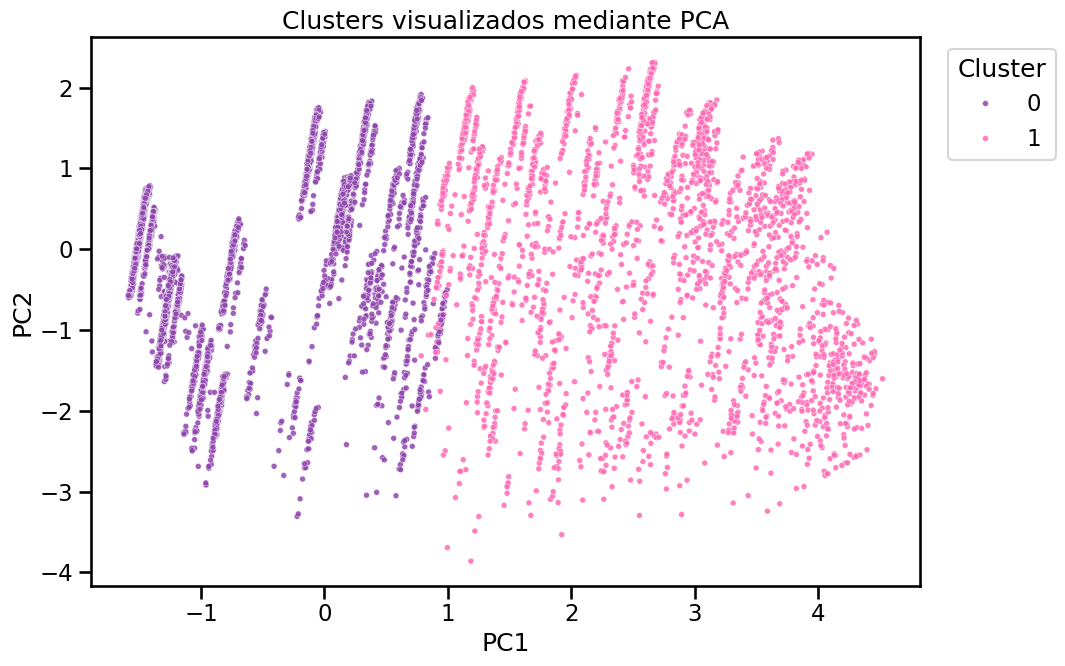

In [10]:
# Se reducen las variables a 2 componentes principales para facilitar la visualización
pca = PCA(n_components=2, random_state=RANDOM_STATE)

# Se transforman los datos
X_pca = pca.fit_transform(X)

print("Dimensión del dataset transformado:", X_pca.shape)

print(
    "Varianza explicada por PC1 y PC2:",
    pca.explained_variance_ratio_
)

# Se crea el dataframe para la visualización
df_plot = pd.DataFrame({
    "PC1": X_pca[:, 0],
    "PC2": X_pca[:, 1],
    "cluster": df_original[cluster_col].astype(str)
})

# Se toma una muestra para mejorar la visualización
df_plot_sample = df_plot.sample(10000, random_state=RANDOM_STATE)

plt.figure(figsize=(11, 7))

sns.scatterplot(
    data=df_plot_sample,
    x="PC1",
    y="PC2",
    hue="cluster",
    palette=["#8e44ad", "#ff69b4"],  # morado y rosado
    s=18,
    alpha=0.85
)

plt.title("Clusters visualizados mediante PCA")
plt.xlabel("PC1")
plt.ylabel("PC2")

plt.legend(
    title="Cluster",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

### Análisis de Resultados

Debido a la alta dimensionalidad del dataset original, se aplicó un Análisis de Componentes Principales (PCA) para reducir el espacio de características a dos componentes principales (PC1 y PC2). Esto permite proyectar y visualizar los clusters en un plano bidimensional. 

Para evitar una sobrecarga visual ("overplotting") dado el volumen de datos original (más de 1 millón de registros), la gráfica se generó utilizando una muestra representativa de 10,000 observaciones.

* **Varianza Explicada:** El primer componente principal (PC1) captura el **35.0%** de la varianza, mientras que el segundo (PC2) captura el **12.5%**. En conjunto, la visualización bidimensional representa aproximadamente el **47.5%** de la información total del dataset original.
* **Separación de los Grupos:** Se observa una delimitación clara entre los dos clusters a lo largo del eje horizontal (PC1). El componente principal 1 es el factor dominante en la diferenciación de ambos grupos.
* **Estructura de los Datos:** La disposición de los puntos en patrones o "bandas" verticales sugiere fuertemente la presencia de variables categóricas o discretas dentro de las características originales, las cuales estructuran la distribución de los datos transformados.